# Policy Evaluation

In this notebook, we evaluate the trained reinforcement learning agents and compare them with traditional pricing strategies.

Strategies compared:

- Fixed Price Strategy
- Time Discount Strategy
- Tabular Q-Learning
- Deep Q-Network (DQN)

The evaluation metric is **Total Revenue per Booking Season**.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import numpy as np
import matplotlib.pyplot as plt

from src.baselines import (
    fixed_price_strategy,
    time_discount_strategy,
)

from src.q_learning import QLearningAgent

from src.dqn import DQNAgent

In [2]:
fixed_revenues = []

for _ in range(100):

    revenue = fixed_price_strategy()

    fixed_revenues.append(revenue)

print("Fixed Price Strategy")

print("Average Revenue :", np.mean(fixed_revenues))

print("Std Revenue :", np.std(fixed_revenues))

print("Minimum Revenue :", np.min(fixed_revenues))

print("Maximum Revenue :", np.max(fixed_revenues))

Fixed Price Strategy
Average Revenue : 1298.2
Std Revenue : 176.705291375216
Minimum Revenue : 860
Maximum Revenue : 1700


In [3]:
discount_revenues = []

for _ in range(100):

    revenue = time_discount_strategy()

    discount_revenues.append(revenue)

print("Time Discount Strategy")

print("Average Revenue :", np.mean(discount_revenues))

print("Std Revenue :", np.std(discount_revenues))

print("Minimum Revenue :", np.min(discount_revenues))

print("Maximum Revenue :", np.max(discount_revenues))

Time Discount Strategy
Average Revenue : 1075.8
Std Revenue : 196.02642678985916
Minimum Revenue : 580
Maximum Revenue : 1540


In [4]:
q_agent = QLearningAgent()

q_agent.q_table = np.load("../models/q_table.npy")

q_revenues = q_agent.evaluate()

print("Q-Learning")

print("Average Revenue :", np.mean(q_revenues))

print("Std Revenue :", np.std(q_revenues))

print("Minimum Revenue :", np.min(q_revenues))

print("Maximum Revenue :", np.max(q_revenues))

Q-Learning
Average Revenue : 1171.8
Std Revenue : 194.97887065012966
Minimum Revenue : 460
Maximum Revenue : 1460


In [5]:
dqn_agent = DQNAgent()

dqn_agent.load_model("../models/best_dqn_model.pth")

dqn_revenues = dqn_agent.evaluate()

print("Deep Q-Network")

print("Average Revenue :", np.mean(dqn_revenues))

print("Std Revenue :", np.std(dqn_revenues))

print("Minimum Revenue :", np.min(dqn_revenues))

print("Maximum Revenue :", np.max(dqn_revenues))

Deep Q-Network
Average Revenue : 1099.2
Std Revenue : 277.7325332041603
Minimum Revenue : 560
Maximum Revenue : 1840


# Revenue Comparison

This visualization compares the average seasonal revenue generated by each pricing strategy.

Higher average revenue indicates better pricing performance over multiple simulated booking seasons.

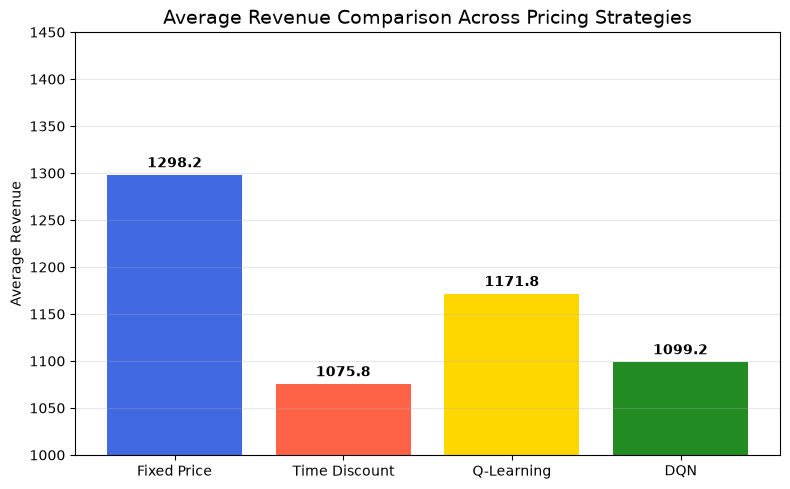

In [6]:
strategies = [
    "Fixed Price",
    "Time Discount",
    "Q-Learning",
    "DQN",
]

average_revenues = [
    np.mean(fixed_revenues),
    np.mean(discount_revenues),
    np.mean(q_revenues),
    np.mean(dqn_revenues),
]

colors = [
    "royalblue",
    "tomato",
    "gold",
    "forestgreen",
]

plt.figure(figsize=(8, 5))

bars = plt.bar(strategies, average_revenues, color=colors)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 8,
        f"{height:.1f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

plt.title("Average Revenue Comparison Across Pricing Strategies", fontsize=14)

plt.ylabel("Average Revenue")

plt.ylim(1000, 1450)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/revenue_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Revenue Distribution

This boxplot compares the revenue distributions of all pricing strategies over multiple simulated booking seasons.

It highlights:

- Median revenue
- Revenue variability
- Best- and worst-case outcomes
- Potential outliers

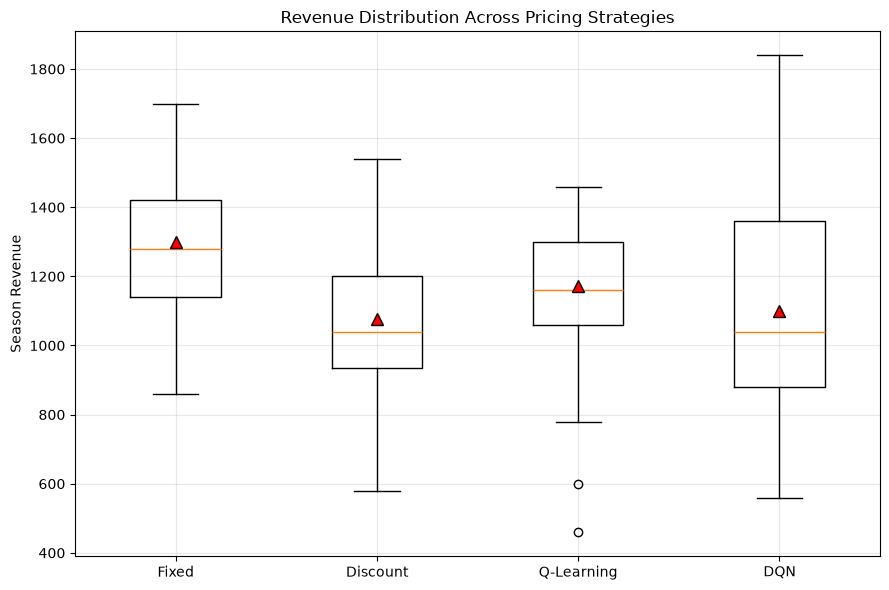

In [7]:
plt.figure(figsize=(9, 6))

plt.boxplot(
    [
        fixed_revenues,
        discount_revenues,
        q_revenues,
        dqn_revenues,
    ],
    tick_labels=[
        "Fixed",
        "Discount",
        "Q-Learning",
        "DQN",
    ],
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markersize": 8,
    },
)

plt.title("Revenue Distribution Across Pricing Strategies")

plt.ylabel("Season Revenue")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/revenue_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [8]:
dqn_agent = DQNAgent()

dqn_agent.load_model("../models/best_dqn_model.pth")

trajectory = dqn_agent.simulate_booking_season()

print(trajectory.keys())

print()

for key, value in trajectory.items():
    print(key)
    print(value)
    print()

dict_keys(['days_left', 'inventory', 'price', 'revenue', 'purchase'])

days_left
[np.int32(15), np.int32(14), np.int32(13), np.int32(12), np.int32(11), np.int32(10), np.int32(9), np.int32(8), np.int32(7), np.int32(6), np.int32(5), np.int32(4), np.int32(3), np.int32(2), np.int32(1)]

inventory
[np.int32(20), np.int32(19), np.int32(19), np.int32(19), np.int32(18), np.int32(18), np.int32(17), np.int32(17), np.int32(17), np.int32(16), np.int32(15), np.int32(15), np.int32(14), np.int32(13), np.int32(13)]

price
[140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140, 140]

revenue
[140, 0, 0, 140, 0, 140, 0, 0, 140, 140, 0, 140, 140, 0, -100]

purchase
[True, False, False, True, False, True, False, False, True, True, False, True, True, False, True]



# Learned Pricing Policy

This figure shows the pricing decisions made by the trained Deep Q-Network (DQN) during a single simulated booking season.

Although the learned policy converged to a stable price in this environment, the visualization demonstrates the policy selected by the reinforcement learning agent at each decision step.

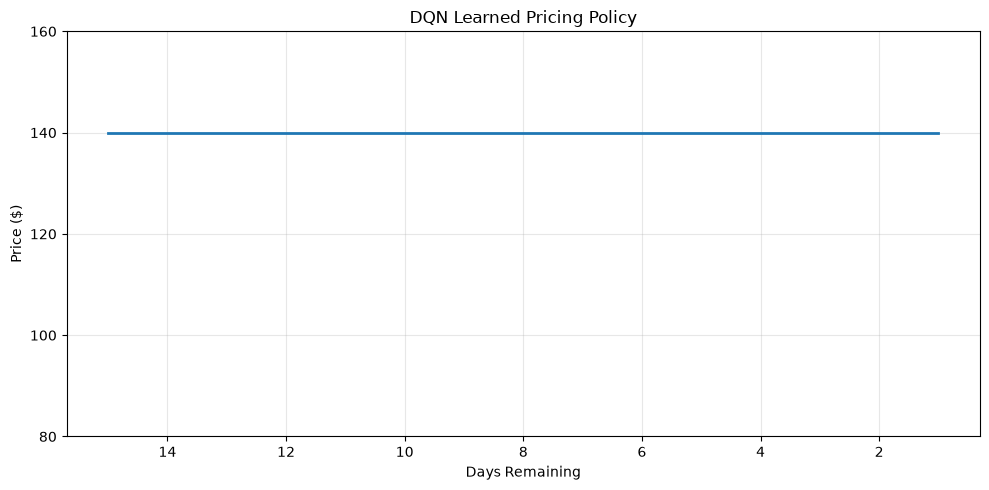

In [13]:
trajectory = dqn_agent.simulate_booking_season()

days = trajectory["days_left"]
prices = trajectory["price"]

plt.figure(figsize=(10, 5))

plt.step(
    days,
    prices,
    where="post",
    linewidth=2,
)

plt.gca().invert_xaxis()

plt.title("DQN Learned Pricing Policy")

plt.xlabel("Days Remaining")

plt.ylabel("Price ($)")

plt.yticks([80, 100, 120, 140, 160])

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/dqn_price_trajectory.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Inventory Depletion

This figure illustrates how the remaining inventory changes throughout a booking season while the trained DQN policy is applied.

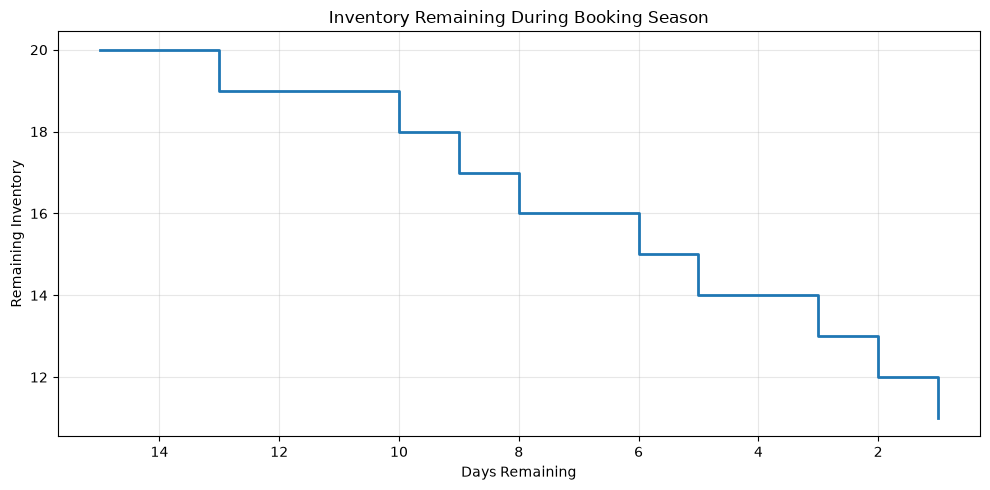

In [14]:
inventory = trajectory["inventory"]

plt.figure(figsize=(10, 5))

plt.step(
    days,
    inventory,
    where="post",
    linewidth=2,
)

plt.gca().invert_xaxis()

plt.title("Inventory Remaining During Booking Season")

plt.xlabel("Days Remaining")

plt.ylabel("Remaining Inventory")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/dqn_inventory_trajectory.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Business Dashboard

The dashboard summarizes the behavior of the trained reinforcement learning agent during one simulated booking season.

The top panel shows the selected prices, while the bottom panel shows inventory depletion over time.

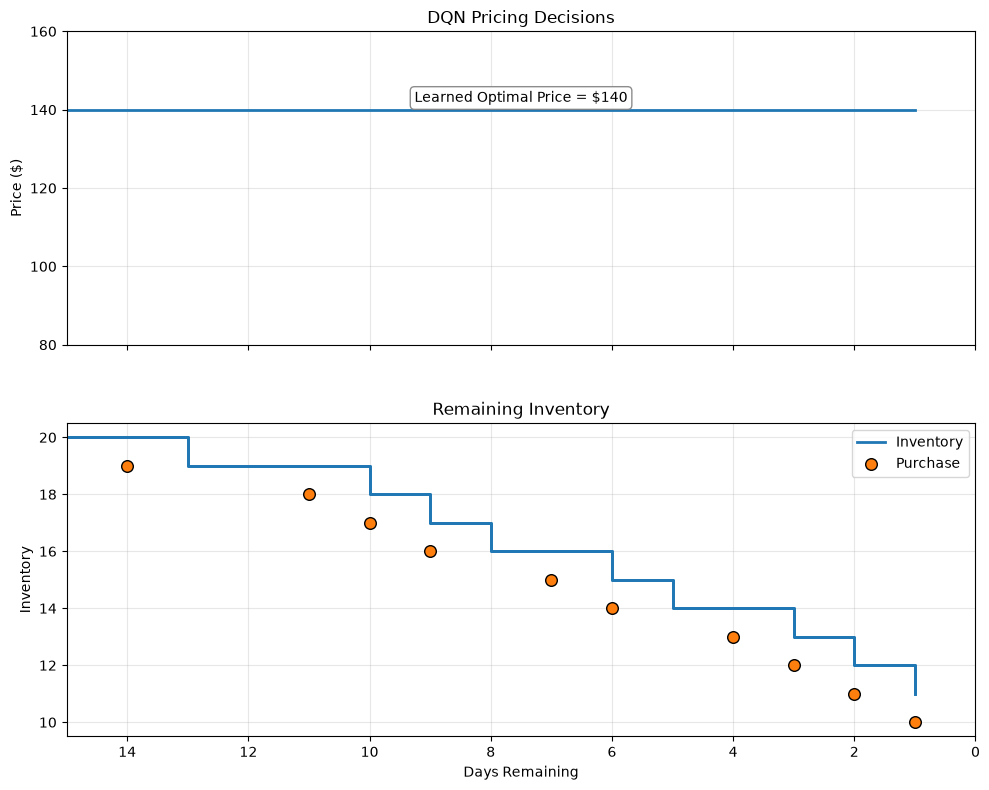

In [22]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
)

# ------------------------
# Price
# ------------------------

axes[0].step(
    days,
    prices,
    where="post",
    linewidth=2,
)

axes[0].invert_xaxis()

axes[0].set_title("DQN Pricing Decisions")

axes[0].set_ylabel("Price ($)")

axes[0].set_yticks([80, 100, 120, 140, 160])

axes[0].grid(alpha=0.3)

axes[0].text(
    7.5,
    142,
    "Learned Optimal Price = $140",
    ha="center",
    fontsize=10,
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9,
    ),
)

# ------------------------
# Inventory
# ------------------------

axes[1].step(
    days,
    inventory,
    where="post",
    linewidth=2,
)

purchase_days = [
    day
    for day, purchased in zip(
        trajectory["days_left"],
        trajectory["purchase"],
    )
    if purchased
]

purchase_inventory = [
    inv - 1
    for inv, purchased in zip(
        trajectory["inventory"],
        trajectory["purchase"],
    )
    if purchased
]

axes[1].step(
    days,
    inventory,
    where="post",
    linewidth=2,
    color="tab:blue",
    label="Inventory",
)

axes[1].scatter(
    purchase_days,
    purchase_inventory,
    s=70,
    color="tab:orange",
    edgecolors="black",
    zorder=3,
    label="Purchase",
)

axes[1].legend()

axes[1].set_title("Remaining Inventory")

axes[1].set_xlabel("Days Remaining")

axes[1].set_ylabel("Inventory")

axes[1].grid(alpha=0.3)

axes[0].set_xlim(15, 0)
plt.tight_layout()

plt.subplots_adjust(hspace=0.25)

plt.savefig(
    "../outputs/figures/business_dashboard.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()